In [1]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from tqdm import tqdm
from pathlib import Path

In [2]:
YEAR = 2021
RAW_XY_FOLDERPATH = Path(f'../data/silver/Xy-{YEAR}')

# Load data

In [3]:
raw_Xy = pd.read_parquet(RAW_XY_FOLDERPATH / "Xy.parquet").reset_index(drop=True)
metadata_df = pd.read_parquet(RAW_XY_FOLDERPATH / "metadata_df.parquet").reset_index(drop=True)

print(f"# rows: {len(raw_Xy)}")
raw_Xy.head(1)

# rows: 915540


,red,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,red_11x11_median,...,ndwi_11x11_var,tci_11x11_median,ndvi_11x11_median,evi_11x11_median,evi2_11x11_median,ndre_b5_11x11_median,ndre_b6_11x11_median,ndre_b7_11x11_median,gndvi_11x11_median,ndwi_11x11_median
0,0.121569,0.121569,0.109804,0.129412,0.007843,0.117647,0.109804,0.129412,0.007843,0.117647,...,-0.230769,0.036183,0.25,0.083682,-0.099099,0.106383,0.050505,0.019608,0.132626,-0.099099


# Train:test:split

In [4]:
# Decide on which region to train for
REGION = 'Ashanti'
region_mask = raw_Xy.region == REGION

# Discard not-in-region data
raw_Xy = raw_Xy[region_mask]
metadata_df = metadata_df[region_mask]
print(f"Discarding out-of-region points: Kept {region_mask.sum()}/{len(region_mask)} ({region_mask.sum()/len(region_mask) * 100:.2f}%)")

# Figure out which folds are for train/val and which for test
test_size = 0.2
region_fold_idxs = metadata_df[region_mask].fold_idx.unique()
n_test_folds = int(np.floor(test_size * len(region_fold_idxs)))
test_fold_idxs = np.random.choice(region_fold_idxs, size=n_test_folds, replace=False)
test_mask = metadata_df.fold_idx.isin(test_fold_idxs)
print(f"{len(test_fold_idxs)}/{len(region_fold_idxs)} regions for testing ({test_mask.sum()} points)")

# Split
Xy_train = raw_Xy[~test_mask]
metadata_df_train = metadata_df[~test_mask]
Xy_test = raw_Xy[test_mask]
metadata_df_test = metadata_df[test_mask]

Discarding out-of-region points: Kept 95807/915540 (10.46%)
200/1000 regions for testing (19086 points)


/tmp/ipykernel_15488/2021917556.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  region_fold_idxs = metadata_df[region_mask].fold_idx.unique()


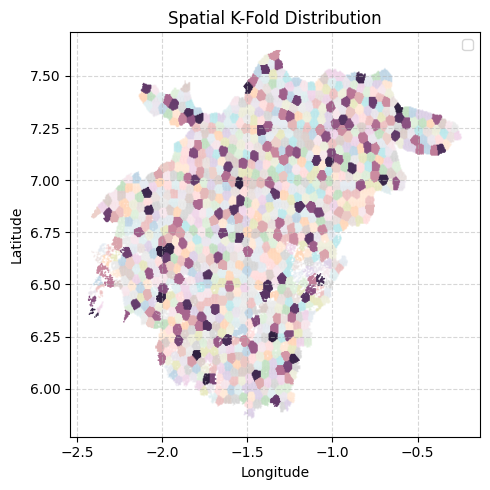

In [6]:
# Plot the folds
plt.figure(figsize=(5, 5))
sns.scatterplot(data=metadata_df[~test_mask], x='lon', y='lat', hue='fold_idx', palette='tab20', s=1, alpha=0.1, edgecolor=None)
sns.scatterplot(data=metadata_df[test_mask], x='lon', y='lat', hue='fold_idx', color='r', s=1, alpha=1, edgecolor=None)

plt.title('Spatial K-Fold Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend([])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Train models

In [7]:
# Build X,y
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Initialize and fit the Dummy Classifier
dummy_clf = DummyClassifier(strategy="stratified")
dummy_clf.fit(X_train, y_train > 0.65)
yhat_test = dummy_clf.predict(X_test)

# Evaluate the baseline
print(f"Baseline Macro F1: {f1_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Precision: {precision_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Recall: {recall_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
print("- Negative (0)")
print(f"- F1: {f1_score(y_test, yhat_test, pos_label=0, zero_division=0):.4f}")
print(f"-- Precision: {precision_score(y_test, yhat_test, pos_label=0, zero_division=0):.4f}")
print(f"-- Recall: {recall_score(y_test, yhat_test, pos_label=0, zero_division=0):.4f}")
print("- Positive (1)")
print(f"- F1: {f1_score(y_test, yhat_test, pos_label=1, zero_division=0):.4f}")
print(f"-- Precision: {precision_score(y_test, yhat_test, pos_label=1, zero_division=0):.4f}")
print(f"-- Recall: {recall_score(y_test, yhat_test, pos_label=1, zero_division=0):.4f}")

Baseline Macro F1: 0.4985
Baseline Macro Precision: 0.4991
Baseline Macro Recall: 0.4992
- Negative (0)
- F1: 0.7300
-- Precision: 0.7152
-- Recall: 0.7455
- Positive (1)
- F1: 0.2671
-- Precision: 0.2829
-- Recall: 0.2529


# Prep hyperparam optimization

In [106]:
import numpy as np
import optuna
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, precision_score, recall_score

def optuna_objective_factory(X, y, groups, n_splits: int = 100):
    # Safely determine max possible splits based on unique groups
    unique_groups = len(np.unique(groups))
    actual_splits = min(n_splits, unique_groups)
    
    if actual_splits < n_splits:
        print(f"Warning: Requested {n_splits} splits, but only found {unique_groups} unique groups. Adjusting n_splits to {actual_splits}.")

    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 15),
            'num_leaves': trial.suggest_int('num_leaves', 10, 256),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'n_jobs': -1,
            'verbose': -1,
            'random_state': 42
        }
        
        gkf = GroupKFold(n_splits=actual_splits)
        
        # Initialize lists to store metrics and raw arrays
        true_f1s, true_precisions, true_recalls = [], [], []
        false_f1s, false_precisions, false_recalls = [], [], []
        all_yhat_vals, all_y_vals = [], []
        
        for train_idx, val_idx in gkf.split(X, y, groups):
            # Safe slicing regardless of whether X/y are pandas DataFrames/Series or numpy arrays
            X_train = X.iloc[train_idx]
            X_val = X.iloc[val_idx]
            y_train = y.iloc[train_idx]
            y_val = y.iloc[val_idx] 
            
            # Fit/predict
            model = lgb.LGBMClassifier(**param)
            model.fit(X_train, y_train)
            yhat_val = model.predict(X_val)
            
            # Calculate and append metrics
            true_f1s.append(f1_score(y_val, yhat_val, zero_division=0))
            true_precisions.append(precision_score(y_val, yhat_val, zero_division=0))
            true_recalls.append(recall_score(y_val, yhat_val, zero_division=0))

            false_f1s.append(f1_score(y_val, yhat_val, zero_division=0, pos_label=0))
            false_precisions.append(precision_score(y_val, yhat_val, zero_division=0, pos_label=0))
            false_recalls.append(recall_score(y_val, yhat_val, zero_division=0, pos_label=0))
            
            all_yhat_vals.append(yhat_val.tolist())
            all_y_vals.append(y_val.tolist())

        # Store tracked data as user attributes in the trial
        trial.set_user_attr('true_f1s', true_f1s)
        trial.set_user_attr('true_precisions', true_precisions)
        trial.set_user_attr('true_recalls', true_recalls)
        trial.set_user_attr('false_f1s', false_f1s)
        trial.set_user_attr('false_precisions', false_precisions)
        trial.set_user_attr('false_recalls', false_recalls)
        trial.set_user_attr('yhat_vals', all_yhat_vals)
        trial.set_user_attr('y_vals', all_y_vals)
        
        return np.median(true_f1s)

    return objective

# Train dummy LGBM baseline

In [107]:
def get_dummy_feature(X):
    features = ["valid_observations"]
    return X[features]
    
# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_dummy_feature(X_train)
X_test = get_dummy_feature(X_test)

X_train.head(1)

,valid_observations
526640,6


In [241]:
def compute_a(y):
    return y.sum() / len(y)

a = compute_a(y_test)
print(f"{REGION}'s test cocoa area proportion (CAP): {a*100:.2f}%")

def compute_ahat(yhat, y_vals, yhat_vals):
    area_proportion_1 = yhat.sum() / len(yhat)
    area_proportion_0 = 1 - area_proportion_1
    
    # Figure out precision/false-omission-rate as the weighted-mean
    cms = [confusion_matrix(y_val, yhat_val, labels=[True, False]) for y_val, yhat_val in zip(y_vals, yhat_vals)] # (tp, fn), (fp, tn)
    tps = [e[0][0] for e in cms]
    fns = [e[0][1] for e in cms]
    tns = [e[1][1] for e in cms]
    fps = [e[1][0] for e in cms]

    # Figure out weighted-averaged TN, ...
    n_vals = np.array([len(e) for e in y_vals])
    tp = np.mean(tps)
    fn = np.mean(fns)
    fp = np.mean(fps)
    tn = np.mean(tns)

    # Compute validation set's metrics
    false_omission_rate = fn / (fn + tn)
    precision = tp / (tp + fp)

    # Compute adjusted unbiased area proportion
    ahat = (area_proportion_1 * precision) + (area_proportion_0 * false_omission_rate)

    # Compute Confidence Interval (Olofsson Variance)
    n_cocoa = tp + fp
    n_non_cocoa = fn + tn

    # Variance contribution from both strata
    var_cocoa = (area_proportion_1 ** 2) * (precision * (1 - precision)) / (n_cocoa - 1)
    var_non_cocoa = (area_proportion_0 ** 2) * (false_omission_rate * (1 - false_omission_rate)) / (n_non_cocoa - 1)
    
    # Standard Error
    se = np.sqrt(var_cocoa + var_non_cocoa)
    
    # Margin of Error for 95% Confidence Interval (Z-score = 1.96)
    margin_of_error = 1.96 * se
    
    ci_lower = max(0.0, ahat - margin_of_error) # Clamp at 0%
    ci_upper = min(1.0, ahat + margin_of_error) # Clamp at 100%

    return ahat, (ci_lower, ci_upper)

Ashanti's test cocoa area proportion (CAP): 28.43%


In [239]:
def train_test_lgbm(X_train, y_train, X_test, y_test, groups, n_splits=100, n_trials=3):
    print("Starting Optuna hyperparameter optimization...")
    study = optuna.create_study(direction="maximize") 
    study.optimize(optuna_objective_factory(X_train, y_train, groups, n_splits), n_trials=n_trials, show_progress_bar=True)
    
    # Build final model
    clf = lgb.LGBMClassifier(**study.best_params)
    clf.fit(X_train, y_train)
    
    yhat_train = clf.predict(X_train)
    yhat_test = clf.predict(X_test)

    # Validation-inferred correction
    yhat_vals = [np.array(e) for e in study.best_trial.user_attrs['yhat_vals']]
    y_vals = [np.array(e) for e in study.best_trial.user_attrs['y_vals']]
    ahat, (ci_lower, ci_upper) = compute_ahat(yhat_test, y_vals, yhat_vals)
    a = compute_a(y_test)
    print(f"{REGION}'s test estimated CAP: {ahat*100:.2f}% ({100 * ahat / a - 100:.2f}% off ETHZ's estimate)")
    print(f"95% Confidence Interval: [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")
    
    print("\n--- OPTIMIZED MODEL EVALUATION ---")
    print("TRAIN")
    print(f"- F1: {f1_score(y_train, yhat_train, zero_division=0):.4f}")
    print(f"- Precision: {precision_score(y_train, yhat_train, zero_division=0):.4f}")
    print(f"- Recall: {recall_score(y_train, yhat_train, zero_division=0):.4f}")
    
    print("\nTEST")
    print(f"- F1: {f1_score(y_test, yhat_test, zero_division=0):.4f}")
    print(f"- Precision: {precision_score(y_test, yhat_test, zero_division=0):.4f}")
    print(f"- Recall: {recall_score(y_test, yhat_test, zero_division=0):.4f}")

    return clf, study.best_trial.user_attrs

train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, n_splits=20, n_trials=1);

[I 2026-06-23 16:33:05,451] A new study created in memory with name: no-name-42c9e7fa-f4de-4841-a14c-c171d19bc118


Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[W 2026-06-23 16:33:07,896] Trial 0 failed with parameters: {'n_estimators': 237, 'learning_rate': 0.014741514141923855, 'max_depth': 7, 'num_leaves': 186, 'subsample': 0.723467487948971, 'colsample_bytree': 0.5749395096352088, 'min_child_samples': 64} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_15488/124706966.py", line 45, in objective
    model.fit(X_train, y_train)
    ~~~~~~~~~^^^^^^^^^^^^^^^^^^
  File "/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
    ~~~~~~~~~~~^
        X,
        ^^
    ...<12 lines>...
        init_model=init_model,
        ^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/home/aga/Documents/clients/forestero/skymap/skymap/.v

KeyboardInterrupt: 

# Train LGBM baseline

In [234]:
# Baseline LGBM
def get_base_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_features(X_train)
X_test = get_base_features(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22
526640,0.035294,0.047059,0.058824,0.133333,0.117647,0.133333,0.117647,0.129412,0.184314,0.14902


In [235]:
clf, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, n_trials=1)

[I 2026-06-23 16:30:39,385] A new study created in memory with name: no-name-f8cace0e-d665-4e4c-aa6c-10f0ff59a48f


Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[W 2026-06-23 16:30:48,744] Trial 0 failed with parameters: {'n_estimators': 226, 'learning_rate': 0.040087473569991386, 'max_depth': 9, 'num_leaves': 149, 'subsample': 0.9034979933108036, 'colsample_bytree': 0.5475855115855525, 'min_child_samples': 84} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_15488/124706966.py", line 45, in objective
    model.fit(X_train, y_train)
    ~~~~~~~~~^^^^^^^^^^^^^^^^^^
  File "/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
    ~~~~~~~~~~~^
        X,
        ^^
    ...<12 lines>...
        init_model=init_model,
        ^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/home/aga/Documents/clients/forestero/skymap/skymap/.

KeyboardInterrupt: 

# Consider the SCL

In [ ]:
# Take into account this SCL
def get_base_and_scl_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl']
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_features(X_train)
X_test = get_base_and_scl_features(X_test)

X_train.head(1)

In [ ]:
clf, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, n_splits=10, n_trials=1)

# Add TCI & other features

In [236]:
# Take into account this SCL
def get_base_and_scl_and_advanced_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl']
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_and_advanced_features(X_train)
X_test = get_base_and_scl_and_advanced_features(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,scl,tci,ndvi,evi,evi2,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi
526640,0.035294,0.047059,0.058824,0.133333,0.117647,0.133333,0.117647,0.129412,0.184314,0.14902,NOT_VEGETATED,0.076961,0.333333,0.084746,-0.220779,-0.014925,0.047619,-0.014925,0.116822,-0.220779


In [ ]:
clf, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, n_splits=20, n_trials=1)

# Keep track of #valid observations

In [222]:
# Take into account this SCL
def get_base_and_scl_and_obs_cnt_and_advanced_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl']
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    features += ['valid_observations']
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_and_obs_cnt_and_advanced_features(X_train)
X_test = get_base_and_scl_and_obs_cnt_and_advanced_features(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,tci,ndvi,evi,evi2,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi,valid_observations
526640,0.035294,0.047059,0.058824,0.133333,0.117647,0.133333,0.117647,0.129412,0.184314,0.14902,...,0.076961,0.333333,0.084746,-0.220779,-0.014925,0.047619,-0.014925,0.116822,-0.220779,6


In [223]:
clf, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, n_splits=20, n_trials=1)

[I 2026-06-23 16:24:56,228] A new study created in memory with name: no-name-08441782-ca75-439c-aec3-00ef03f109fb


Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-23 16:25:07,641] Trial 0 finished with value: 0.6754360894376328 and parameters: {'n_estimators': 156, 'learning_rate': 0.016867223356643056, 'max_depth': 11, 'num_leaves': 30, 'subsample': 0.9737558364806759, 'colsample_bytree': 0.7138821846764061, 'min_child_samples': 80}. Best is trial 0 with value: 0.6754360894376328.

--- OPTIMIZED MODEL EVALUATION ---
TRAIN
- F1: 0.6826
- Precision: 0.7155
- Recall: 0.6527

TEST
- F1: 0.6874
- Precision: 0.7483
- Recall: 0.6356


# Keep track of cloud confidence

In [225]:
# Take into account cloud confidence
def get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl']
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    features += ['valid_observations']
    features += ['cloud_confidence']
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(X_train)
X_test = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,ndvi,evi,evi2,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi,valid_observations,cloud_confidence
526640,0.035294,0.047059,0.058824,0.133333,0.117647,0.133333,0.117647,0.129412,0.184314,0.14902,...,0.333333,0.084746,-0.220779,-0.014925,0.047619,-0.014925,0.116822,-0.220779,6,0


In [226]:
clf, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, n_splits=20, n_trials=1)

[I 2026-06-23 16:26:03,465] A new study created in memory with name: no-name-275b5708-6a82-40ee-ab05-d80ea0c3bb72


Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-23 16:26:36,752] Trial 0 finished with value: 0.6968919086215308 and parameters: {'n_estimators': 455, 'learning_rate': 0.014666307064242308, 'max_depth': 7, 'num_leaves': 26, 'subsample': 0.908091450887311, 'colsample_bytree': 0.990171208187766, 'min_child_samples': 44}. Best is trial 0 with value: 0.6968919086215308.

--- OPTIMIZED MODEL EVALUATION ---
TRAIN
- F1: 0.7090
- Precision: 0.7088
- Recall: 0.7093

TEST
- F1: 0.7175
- Precision: 0.7452
- Recall: 0.6917


# Rely on neighbor pixels

In [237]:
# Take into account cloud confidence
def get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features_and_neighbor(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl']
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    features += ['valid_observations']
    features += ['cloud_confidence']
    features += [e for e in X.columns if any(k in e for k in ['3x3', '5x5', '11x11'])]
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features_and_neighbor(X_train)
X_test = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features_and_neighbor(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,ndwi_11x11_var,tci_11x11_median,ndvi_11x11_median,evi_11x11_median,evi2_11x11_median,ndre_b5_11x11_median,ndre_b6_11x11_median,ndre_b7_11x11_median,gndvi_11x11_median,ndwi_11x11_median
526640,0.035294,0.047059,0.058824,0.133333,0.117647,0.133333,0.117647,0.129412,0.184314,0.14902,...,-0.722222,0.081111,0.318182,0.077951,-0.236842,0.0,0.0625,0.0,0.109375,-0.236842


In [240]:
clf, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, n_splits=5, n_trials=1)

[I 2026-06-23 16:33:17,223] A new study created in memory with name: no-name-c14f76ce-3379-45d7-b919-997cedacd0b2


Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-23 16:33:34,935] Trial 0 finished with value: 0.7893924512417567 and parameters: {'n_estimators': 276, 'learning_rate': 0.05804164139643417, 'max_depth': 7, 'num_leaves': 15, 'subsample': 0.6632198954276973, 'colsample_bytree': 0.8752770798467759, 'min_child_samples': 55}. Best is trial 0 with value: 0.7893924512417567.
Ashanti's test estimated CAP: 26.71% (-6.04% off ETHZ's estimate)
95% Confidence Interval: [26.22%, 27.21%]

--- OPTIMIZED MODEL EVALUATION ---
TRAIN
- F1: 0.8156
- Precision: 0.8082
- Recall: 0.8231

TEST
- F1: 0.7922
- Precision: 0.8060
- Recall: 0.7788


# Use TCA
https://en.wikipedia.org/wiki/Tasseled_cap_transformation

# Use clustering min ?